## <center> **Banking Churn Prediction Using Decision Trees** </center>
---

### Step 01: Imports

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier


### Step 02: Load the Dataset

In [48]:
df = pd.read_csv("Churn_dataset.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Step 03: Shape of the data

In [3]:
df.shape

(10000, 14)

### Step 04: Basic Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 976.6+ KB


### Step 05: Statistical Summary of data

In [5]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### Step 06: Evaluate the Imbalance

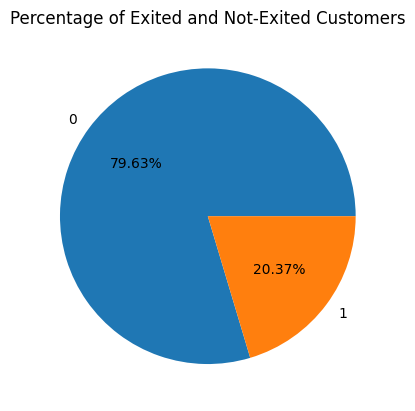

In [32]:
x = df["Exited"].value_counts()

plt.pie(
    x= x.values,
    labels= x.index,
    autopct= "%.2f%%"
)

plt.title("Percentage of Exited and Not-Exited Customers")
plt.show()

- Data is Imbalanced

### Step 07: Number of Exited and Not-Exited Customers

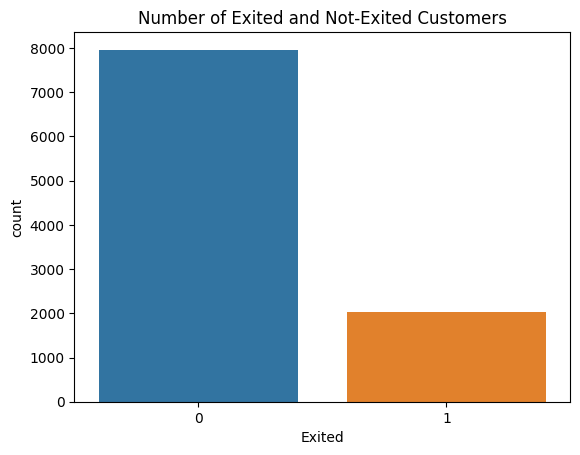

In [8]:
sns.countplot(
    x= df["Exited"]
)

plt.title("Number of Exited and Not-Exited Customers")
plt.show()

### Step 08: Exited and Not-Exited Customers by Gender

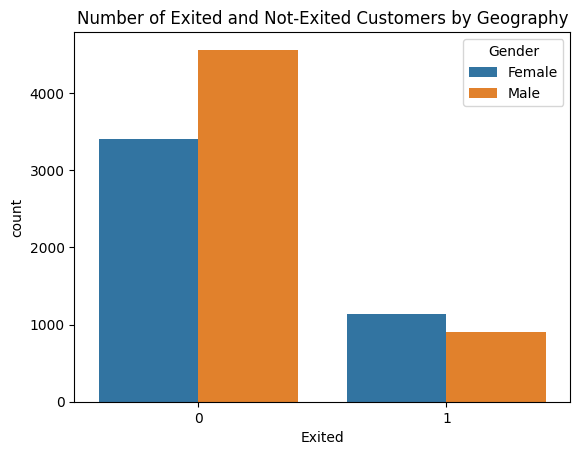

In [12]:
sns.countplot(
    x= df["Exited"],
    hue= df["Gender"]
)

plt.title("Number of Exited and Not-Exited Customers by Gender")
plt.show()

### Step 09: Exited and Not-Exited Customers by Geography

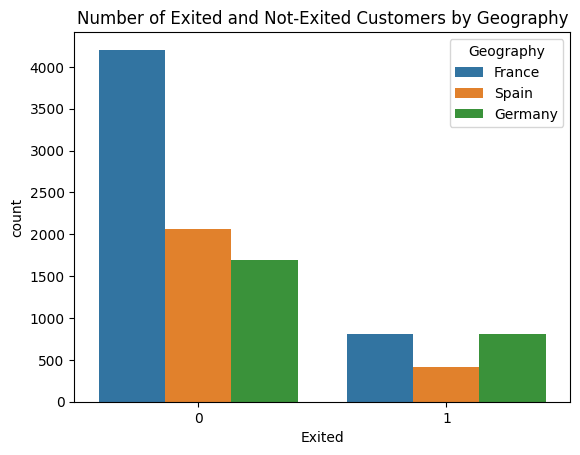

In [11]:
sns.countplot(
    x= df["Exited"],
    hue= df["Geography"]
)

plt.title("Number of Exited and Not-Exited Customers by Geography")
plt.show()

### Step 10: Age based on Credit Score

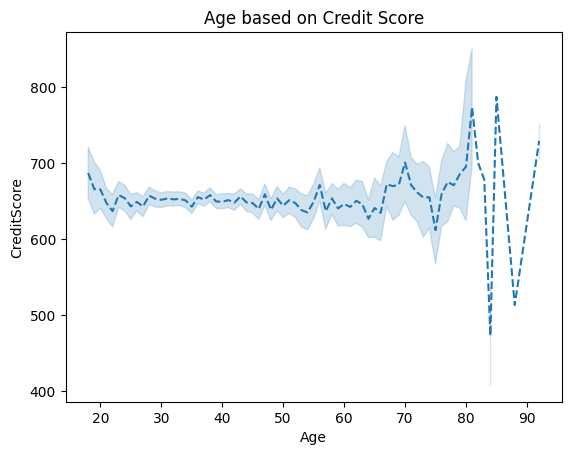

In [23]:
sns.lineplot(
    x= df["Age"],
    y= df["CreditScore"],
    linestyle= "dashed"
)

plt.title("Age based on Credit Score")
plt.show()

### Step 11: Distribution of Age

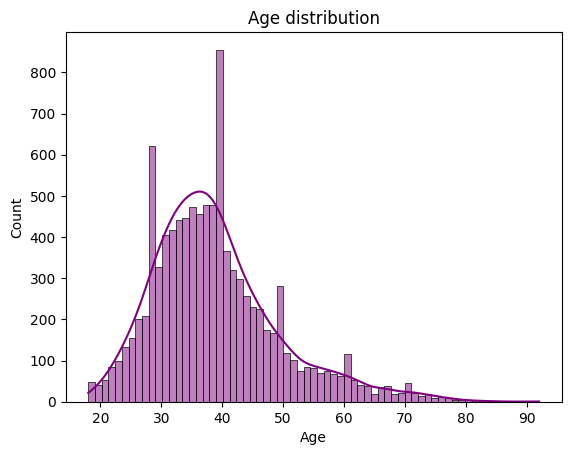

In [34]:
sns.histplot(
    x= df["Age"],
    kde=True,
    color="purple"
)

plt.title("Age distribution")
plt.show()

### Step 12: Distribution of Balance

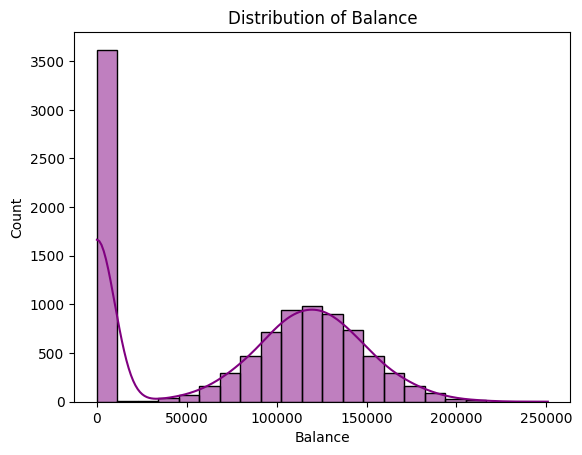

In [37]:
sns.histplot(
    x= df["Balance"],
    kde=True,
    color="purple"
)

plt.title("Distribution of Balance")
plt.show()

### Step 13: Check for null values

In [45]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

### Step 14: Drop Irrelavent columns

In [49]:
df.drop(columns=["RowNumber", "CustomerId", "Surname"], axis= 1, inplace=True)

### Step 15: Encode Categorical Columns into Numeric

In [50]:
df["Geography"] = df["Geography"].map({"France": 1, "Spain": 2, "Germany": 3})
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

### Step 16: Features and Target

In [51]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

### Step 17: Shape of features and Target

In [52]:
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (10000, 10)
Shape of y: (10000,)


### Step 18: Training and Test Sets

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Step 19: Shape of Training and Test  Sets

In [54]:
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (8000, 10)
Shape of X_test: (2000, 10)
Shape of y_train: (8000,)
Shape of y_test: (2000,)


### Step 20: Initialize model

In [55]:
estimator = DecisionTreeClassifier(class_weight="balanced", random_state=42)

### Step 21: Hyperparameter Tunning Using GridSearchCV

In [56]:
param_grid = {
    "max_depth": [3, 5, 7, 9, 10, 11, 13],
    "min_samples_split": [5, 7, 8, 10, 13, 15,17]

}

cv = StratifiedKFold(n_splits=17, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator= estimator,
    param_grid= param_grid,
    cv= cv,
    scoring= "recall",
    n_jobs=9
)

### Step 22: Train model

In [212]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=17, random_state=42, shuffle=True),
             estimator=DecisionTreeClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=9,
             param_grid={'max_depth': [3, 5, 7, 9, 10, 11, 13],
                         'min_samples_split': [5, 7, 8, 10, 13, 15, 17]},
             scoring='recall')

### Step 23: Best Parameters

In [213]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': 7, 'min_samples_split': 17}
0.7342943756449949


### Step 24: Make Predictions

In [214]:
y_pred = grid_search.predict(X_test)

### Step 25: Evaluate model

In [215]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.75      0.83      1593
           1       0.44      0.74      0.55       407

    accuracy                           0.75      2000
   macro avg       0.68      0.75      0.69      2000
weighted avg       0.82      0.75      0.77      2000



### Step: 25: Match Train and Test Accuracy (Check Overfitting)

In [210]:
print("Train score:", grid_search.score(X_train, y_train))
print("Test score:", grid_search.score(X_test, y_test))

Train score: 0.8134969325153374
Test score: 0.7444717444717445
